<a href="https://colab.research.google.com/github/JaswanthJavangula/ML_Practise/blob/main/1ML%20JAshu/Decision%20Tree%20-%20Reg%26Class/DECISION_Tree_Classifier_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
iris = load_iris()
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df["target"]= iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [4]:
X = df.drop("target",axis=1)
y = df["target"]

In [5]:
y.head(3)

,target
0,0
1,0
2,0


In [6]:
X.head(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


In [7]:
from numpy.random.mtrand import random
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=10)
# doesnt not require standartzation or normalization in DT

In [8]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train,y_train)


DecisionTreeClassifier()

[Text(0.375, 0.9, 'x[3] <= 0.75\ngini = 0.666\nsamples = 100\nvalue = [35, 31, 34]'),
 Text(0.25, 0.7, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.3125, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[2] <= 4.75\ngini = 0.499\nsamples = 65\nvalue = [0, 31, 34]'),
 Text(0.4375, 0.8, '  False'),
 Text(0.25, 0.5, 'x[3] <= 1.6\ngini = 0.064\nsamples = 30\nvalue = [0, 29, 1]'),
 Text(0.125, 0.3, 'gini = 0.0\nsamples = 29\nvalue = [0, 29, 0]'),
 Text(0.375, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.75, 0.5, 'x[3] <= 1.75\ngini = 0.108\nsamples = 35\nvalue = [0, 2, 33]'),
 Text(0.625, 0.3, 'x[3] <= 1.55\ngini = 0.48\nsamples = 5\nvalue = [0, 2, 3]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.75, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2, 0]'),
 Text(0.875, 0.3, 'gini = 0.0\nsamples = 30\nvalue = [0, 0, 30]')]

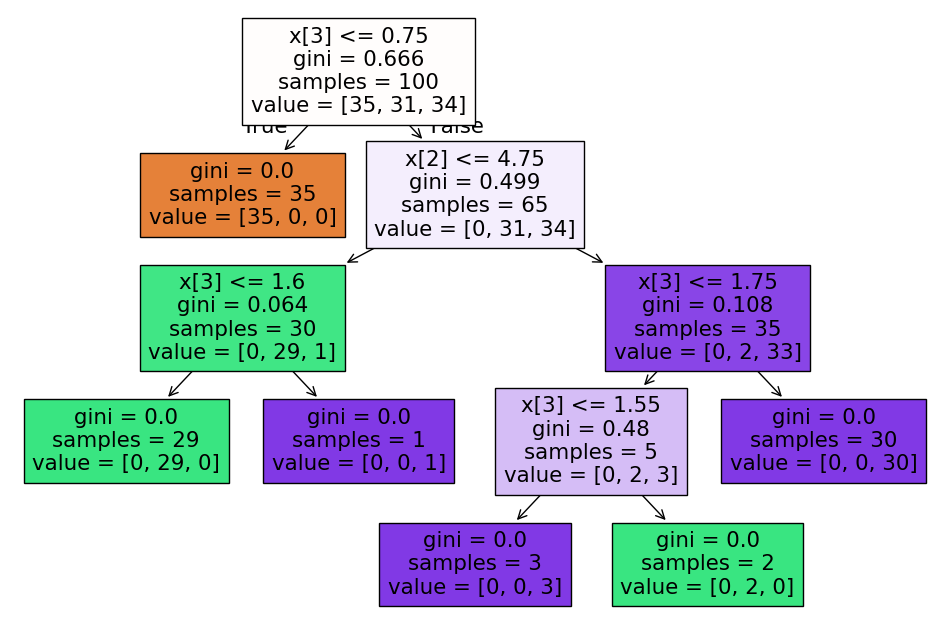

In [9]:
# visulaize the DT
from sklearn import tree
plt.figure(figsize= (12,8))
tree.plot_tree(dtc,filled=True)


In [10]:
y_pred = dtc.predict(X_test)

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[15  0  0]
 [ 0 15  4]
 [ 0  1 15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      0.79      0.86        19
           2       0.79      0.94      0.86        16

    accuracy                           0.90        50
   macro avg       0.91      0.91      0.90        50
weighted avg       0.91      0.90      0.90        50



### decision tree classifier prepruning and hyperparameter tuning

In [16]:
param_grid= {
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter":["best", "random"],
    "max_depth": [2, 3, 5, 10, 20],
    "max_features" : ["sqrt", "log2", "auto"]
}

In [21]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import GridSearchCV
dtc1 = DecisionTreeClassifier()
gs = GridSearchCV(dtc1,param_grid,cv=5,scoring = "accuracy")
gs.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [2, 3, 5, 10, 20],
                         'max_features': ['sqrt', 'log2', 'auto'],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [22]:
gs.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [24]:
gs.best_score_

np.float64(0.96)

In [26]:
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
y_pred1 = gs.predict(X_test)
print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))
print(accuracy_score(y_test,y_pred1))

[[15  0  0]
 [ 0 16  3]
 [ 0  1 15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      0.84      0.89        19
           2       0.83      0.94      0.88        16

    accuracy                           0.92        50
   macro avg       0.92      0.93      0.92        50
weighted avg       0.92      0.92      0.92        50

0.92
